In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms, models
from torch.utils.data import DataLoader, Subset
import numpy as np
import random

# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# Set random seed for reproducibility
random.seed(42)
torch.manual_seed(42)


In [ ]:
print(device)

cuda


In [2]:

# --------------------------------------------------------------------------------
# Online Dataset Paths for Various Datasets
# --------------------------------------------------------------------------------
CIFAR10_PATH = "https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz"
CIFAR100_PATH = "https://www.cs.toronto.edu/~kriz/cifar-100-python.tar.gz"
IMAGENET_PATH = "https://image-net.org/download-images"
PACS_PATH = "https://github.com/MachineLearning2021/PACS/archive/refs/heads/main.zip"
MNIST_PATH = "http://yann.lecun.com/exdb/mnist/"

print('y')

y


In [3]:
# Unified transformations for CIFAR-10
transform_cifar10 = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

# Train and Test datasets
cifar10_train = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_cifar10)
cifar10_test = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_cifar10)

# Dataloaders
cifar10_train_loader = DataLoader(cifar10_train, batch_size=64, shuffle=True)
cifar10_test_loader = DataLoader(cifar10_test, batch_size=64, shuffle=False)


100%|██████████| 170M/170M [00:04<00:00, 41.4MB/s]


Extracting ./data/cifar-10-python.tar.gz to ./data
Files already downloaded and verified


In [4]:
import torch.nn as nn
import torch.nn.functional as F

transform_m = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_dataset_m = datasets.MNIST(root='./data', train=True, transform=transform_m, download=True)
test_dataset_m = datasets.MNIST(root='./data', train=False, transform=transform_m, download=True)

train_loader_m = DataLoader(train_dataset_m, batch_size=100, shuffle=True)
test_loader_m = DataLoader(test_dataset_m, batch_size=100, shuffle=False)


Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 9.91M/9.91M [00:00<00:00, 16.2MB/s]


Extracting ./data/MNIST/raw/train-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 28.9k/28.9k [00:00<00:00, 494kB/s]


Extracting ./data/MNIST/raw/train-labels-idx1-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 1.65M/1.65M [00:00<00:00, 4.47MB/s]


Extracting ./data/MNIST/raw/t10k-images-idx3-ubyte.gz to ./data/MNIST/raw

Failed to download (trying next):
HTTP Error 403: Forbidden



100%|██████████| 4.54k/4.54k [00:00<00:00, 4.44MB/s]

Extracting ./data/MNIST/raw/t10k-labels-idx1-ubyte.gz to ./data/MNIST/raw



In [5]:
# Define the training function
def backprop_deep(train_loader, net, T, gamma=0.001, rho=0.9):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.SGD(net.parameters(), lr=gamma, momentum=rho)

    for epoch in range(T):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = net(inputs)

            loss = criterion(outputs, labels)

            loss.backward()

            optimizer.step()

            # Print statistics
            running_loss += loss.item()
            if i % 100 == 99:
                print(f"[Epoch {epoch + 1}, Batch {i + 1}] loss: {running_loss / 100:.3f}")
                running_loss = 0.0


In [12]:
def load_pretrained_model(model_name, num_classes=10, device='cpu'):
    """
    Loads a pretrained model and adapts its final classifier for the specified number of classes.
    """
    if model_name in ['cifar10', 'cifar100', 'mnist']:

        if model_name == 'cifar100':
            teacher = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar100_resnet20", pretrained=True)
            in_features = teacher.fc.in_features
            teacher.fc = nn.Linear(in_features, 10)
            print(f"CIFAR-100")
            finetune_teacher(teacher, cifar10_train, cifar10_test, device=device, epochs=5, lr=1e-3)
        elif model_name == 'cifar10':
            teacher = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
            teacher.fc = nn.Linear(teacher.fc.in_features, 10)
            print(f"CIFAR-10")
    elif model_name == 'imagenet':
          teacher = models.resnet50(pretrained=True)
          teacher.fc = nn.Linear(2048, 10)
          print(f"ImageNet")
          finetune_teacher(teacher, cifar10_train, cifar10_test, device=device, epochs=5, lr=1e-3)

    return teacher.to(device)


In [6]:
def test_model(model, test_loader):
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    print(f"Accuracy: {100 * correct / total:.2f}%")
    return 100 * correct / total

In [7]:
def finetune_teacher(teacher, train_dataset, test_dataset, device='cpu', epochs=5, lr=1e-3):
    """
    Fine-tunes a teacher model and evaluates it on the test set.
    """
    train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    if torch.cuda.is_available():
        teacher.to(device)
    if teacher.fc.in_features == 512:

        teacher.train()
        optimizer = optim.Adam(teacher.parameters(), lr=lr)
        criterion = nn.CrossEntropyLoss()

        for epoch in range(epochs):
            total_loss = 0.0
            for inputs, targets in train_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                optimizer.zero_grad()
                outputs = teacher(inputs)
                loss = criterion(outputs, targets)
                loss.backward()
                optimizer.step()

                total_loss += loss.item()

            print(f"[Fine-tune MNIST] Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}")

        teacher.eval()
        correct = 0
        total = 0
        with torch.no_grad():
            for inputs, targets in test_loader:
                inputs, targets = inputs.to(device), targets.to(device)

                outputs = teacher(inputs)
                _, predicted = outputs.max(1)
                correct += (predicted == targets).sum().item()
                total += targets.size(0)

        accuracy = 100 * correct / total
        print(f"[Evaluate MNIST Teacher] Accuracy: {accuracy:.2f}%")

    for param in teacher.parameters():
        param.requires_grad = False
    for param in teacher.fc.parameters():
        param.requires_grad = True

    teacher.train()
    optimizer = optim.Adam(teacher.fc.parameters(), lr=lr)  # Only fine-tune the final layer
    criterion = nn.CrossEntropyLoss()

    for epoch in range(epochs):
        total_loss = 0.0
        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = teacher(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

        print(f"[Fine-tune] Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}")

In [8]:
def distillation_loss(student_outputs, teacher_outputs, targets, temperature=3.0, alpha=0.5):
    ce_loss = nn.CrossEntropyLoss()(student_outputs, targets)
    teacher_soft = nn.functional.softmax(teacher_outputs / temperature, dim=1)
    student_log_soft = nn.functional.log_softmax(student_outputs / temperature, dim=1)
    kl_div = nn.functional.kl_div(student_log_soft, teacher_soft, reduction='batchmean') * (temperature ** 2)
    return alpha * ce_loss + (1 - alpha) * kl_div


In [9]:
def calculate_reliability(logits,lambd1=0.7,lambd2=0.3):
    probs = torch.nn.functional.softmax(logits, dim=1)
    entropy = -torch.sum(probs * torch.log(probs + 1e-10), dim=1).mean()
    diversity = -torch.mean(probs.mean(dim=0) * torch.log(probs.mean(dim=0) + 1e-10))
    return 1 / (entropy*lambd1 - diversity*lambd2 + 1e-10)

In [10]:
import matplotlib.pyplot as plt

def distill_student(teachers, student, train_loader, device='cpu', epochs=10, lr=1e-3, lambda1=0.7, lambda2=0.3, adaptive_weights=False):
    optimizer = optim.Adam(student.parameters(), lr=lr)
    student.train()

    accuracies_train = []  # List to store training accuracy for each epoch
    accuracies_test = []   # List to store test accuracy for each epoch

    for epoch in range(epochs):
        total_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for inputs, targets in train_loader:
            inputs, targets = inputs.to(device), targets.to(device)

            teacher_outputs_list = [teacher(inputs).detach() for teacher in teachers]
            student_outputs = student(inputs)

            if adaptive_weights:
                reliabilities = [calculate_reliability(logits, lambda1, lambda2) for logits in teacher_outputs_list]
                weights = torch.tensor(reliabilities).to(device) / torch.sum(torch.tensor(reliabilities).to(device))
                combined_teacher_outputs = sum(w * logits for w, logits in zip(weights, teacher_outputs_list))
            else:
                combined_teacher_outputs = sum(teacher_outputs_list) / len(teacher_outputs_list)

            loss = distillation_loss(student_outputs, combined_teacher_outputs, targets, temperature=3.0, alpha=0.5)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item()

            # Calculate training accuracy for this batch
            _, predicted = student_outputs.max(1)
            correct_predictions += (predicted == targets).sum().item()
            total_samples += targets.size(0)

        # Calculate and store accuracies
        epoch_train_accuracy = 100 * correct_predictions / total_samples
        accuracies_train.append(epoch_train_accuracy)

        # Evaluate the student model on the test set
        epoch_test_accuracy = test_model(student, cifar10_test_loader)
        accuracies_test.append(epoch_test_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {total_loss / len(train_loader):.4f}, "
              f"Train Accuracy: {epoch_train_accuracy:.2f}%, Test Accuracy: {epoch_test_accuracy:.2f}%")

    # Plot training and test accuracies
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, epochs + 1), accuracies_train, marker='o', label='Training Accuracy')
    plt.plot(range(1, epochs + 1), accuracies_test, marker='s', label='Test Accuracy', linestyle='--')
    plt.title('Training and Test Accuracies During Distillation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.xticks(range(1, epochs + 1))
    plt.grid()
    plt.legend()
    plt.show()



In [14]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

teacher_names = ['cifar10', 'cifar100', 'imagenet', 'mnist']
teacher_cifar100 = load_pretrained_model('cifar100', device=device)





/usr/local/lib/python3.10/dist-packages/torch/hub.py:330: UserWarning: You are about to download and run code from an untrusted repository. In a future release, this won't be allowed. To add the repository to your trusted list, change the command to {calling_fn}(..., trust_repo=False) and a command prompt will appear asking for an explicit confirmation of trust, or load(..., trust_repo=True), which will assume that the prompt is to be answered with 'yes'. You can also use load(..., trust_repo='check') which will only prompt for confirmation if the repo is not already trusted. This will eventually be the default behaviour
  warnings.warn(
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/zipball/master" to /root/.cache/torch/hub/master.zip
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar100_resnet20-23dac2f1.pt" to /root/.cache/torch/hub/checkpoints/cifar100_resnet20-23dac2f1.pt
100%|██████████| 1.11M/1.11M [00:00<00:00, 29.0MB

CIFAR-100
[Fine-tune] Epoch [1/5], Loss: 1.2139
[Fine-tune] Epoch [2/5], Loss: 0.8976
[Fine-tune] Epoch [3/5], Loss: 0.8677
[Fine-tune] Epoch [4/5], Loss: 0.8464
[Fine-tune] Epoch [5/5], Loss: 0.8384


In [15]:
teacher_imagenet = load_pretrained_model('imagenet', device=device)


/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth
100%|██████████| 97.8M/97.8M [00:00<00:00, 155MB/s]


ImageNet
[Fine-tune] Epoch [1/5], Loss: 1.7684
[Fine-tune] Epoch [2/5], Loss: 1.6518
[Fine-tune] Epoch [3/5], Loss: 1.6205
[Fine-tune] Epoch [4/5], Loss: 1.5968
[Fine-tune] Epoch [5/5], Loss: 1.5930


In [ ]:
test_model(teacher_imagenet, cifar10_test_loader)

Accuracy: 46.59%


In [13]:
class LeNet(nn.Module):
    def __init__(self, num_classes=10):
        super(LeNet, self).__init__()
        self.conv1 = nn.Conv2d(1, 6, kernel_size=5)
        self.conv2 = nn.Conv2d(6, 16, kernel_size=5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, num_classes)

    def forward(self, x):
        x = nn.ReLU()(nn.MaxPool2d(2)(self.conv1(x)))
        x = nn.ReLU()(nn.MaxPool2d(2)(self.conv2(x)))
        x = x.view(x.size(0), -1)
        x = nn.ReLU()(self.fc1(x))
        x = nn.ReLU()(self.fc2(x))
        return self.fc3(x)

In [16]:
teacher_mnist = LeNet()
teacher_mnist.to(device)
backprop_deep(train_loader_m, teacher_mnist, T=3)


[Epoch 1, Batch 100] loss: 2.302
[Epoch 1, Batch 200] loss: 2.283
[Epoch 1, Batch 300] loss: 2.255
[Epoch 1, Batch 400] loss: 2.187
[Epoch 1, Batch 500] loss: 1.958
[Epoch 1, Batch 600] loss: 1.308
[Epoch 2, Batch 100] loss: 0.722
[Epoch 2, Batch 200] loss: 0.499
[Epoch 2, Batch 300] loss: 0.424
[Epoch 2, Batch 400] loss: 0.358
[Epoch 2, Batch 500] loss: 0.325
[Epoch 2, Batch 600] loss: 0.306
[Epoch 3, Batch 100] loss: 0.268
[Epoch 3, Batch 200] loss: 0.240
[Epoch 3, Batch 300] loss: 0.228
[Epoch 3, Batch 400] loss: 0.217
[Epoch 3, Batch 500] loss: 0.207
[Epoch 3, Batch 600] loss: 0.187


In [17]:
class AdaptedLeNet(nn.Module):
    def __init__(self, teacher):
        super(AdaptedLeNet, self).__init__()
        self.teacher = teacher

    def forward(self, x):
        x = x.mean(dim=1, keepdim=True)
        x = nn.functional.interpolate(x, size=(28, 28))
        return self.teacher(x)


In [18]:
teacher_mnist = AdaptedLeNet(teacher_mnist)
teacher_mnist.to(device)

AdaptedLeNet(
  (teacher): LeNet(
    (conv1): Conv2d(1, 6, kernel_size=(5, 5), stride=(1, 1))
    (conv2): Conv2d(6, 16, kernel_size=(5, 5), stride=(1, 1))
    (fc1): Linear(in_features=256, out_features=120, bias=True)
    (fc2): Linear(in_features=120, out_features=84, bias=True)
    (fc3): Linear(in_features=84, out_features=10, bias=True)
  )
)

In [19]:
"""
import random

class AddGaussianNoise:
    def __init__(self, mean=0.0, std=0.1):
        self.mean = mean
        self.std = std

    def __call__(self, tensor):
        return tensor + torch.randn_like(tensor) * self.std + self.mean

class ConditionalGaussianNoise:
    def __init__(self, mean=0.0, std=0.1, noise_probability=0.5):
        self.mean = mean
        self.std = std
        self.noise_probability = noise_probability

    def __call__(self, tensor):
        if random.random() < self.noise_probability:
            return tensor + torch.randn_like(tensor) * self.std + self.mean
        return tensor

# Data transformations
transform_train_n = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
    ConditionalGaussianNoise(mean=0.0, std=1.5, noise_probability=0.85),  # Add noise to 70% of training samples
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

transform_test_n = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5, 0.5, 0.5), (0.5, 0.5, 0.5)),
])

train_dataset_n = datasets.CIFAR10(root='./data', train=True, download=True, transform=transform_train_n)
test_dataset_n = datasets.CIFAR10(root='./data', train=False, download=True, transform=transform_test_n)

train_loader_n = DataLoader(train_dataset_n, batch_size=128, shuffle=True)
test_loader_n = DataLoader(test_dataset_n, batch_size=128, shuffle=False)
"""

teacher_cifar10_2 = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
teacher_cifar10_2.fc = nn.Linear(teacher_cifar10_2.fc.in_features, 10)
teacher_cifar10_2.to(device)
for param in teacher_cifar10_2.parameters():
    param.requires_grad = False

for param in teacher_cifar10_2.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(teacher_cifar10_2.fc.parameters(), lr=0.01, momentum=0.9)

def fine_tune(model, train_loader, criterion, optimizer, num_epochs=20, stop_early=True):
    model.train()
    for epoch in range(num_epochs):
        running_loss = 0.0
        for i, (inputs, labels) in enumerate(train_loader):
            inputs, labels = inputs.to(device), labels.to(device)

            optimizer.zero_grad()

            outputs = model(inputs)
            loss = criterion(outputs, labels)


            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            if i % 100 == 99:
                print(f"[Epoch {epoch + 1}, Batch {i + 1}] Loss: {running_loss / 100:.3f}")
                running_loss = 0.0
            if stop_early:
              if i == 4:
                break

        if stop_early:
          if  epoch == 1:
            break
fine_tune(teacher_cifar10_2, cifar10_train_loader, criterion, optimizer, num_epochs=5, stop_early=True)


_=test_model(teacher_cifar10_2, cifar10_test_loader)




Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master
Downloading: "https://github.com/chenyaofo/pytorch-cifar-models/releases/download/resnet/cifar10_resnet20-4118986f.pt" to /root/.cache/torch/hub/checkpoints/cifar10_resnet20-4118986f.pt
100%|██████████| 1.09M/1.09M [00:00<00:00, 27.4MB/s]


Accuracy: 78.09%


In [20]:
teacher_cifar10 = torch.hub.load("chenyaofo/pytorch-cifar-models", "cifar10_resnet20", pretrained=True)
teacher_cifar10.fc = nn.Linear(teacher_cifar10.fc.in_features, 10)
teacher_cifar10.to(device)

for param in teacher_cifar10.parameters():
    param.requires_grad = False

for param in teacher_cifar10.fc.parameters():
    param.requires_grad = True

criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(teacher_cifar10.fc.parameters(), lr=0.01, momentum=0.9)
fine_tune(teacher_cifar10, cifar10_train_loader, criterion, optimizer, num_epochs=2, stop_early=False)

_=test_model(teacher_cifar10, cifar10_test_loader)

Using cache found in /root/.cache/torch/hub/chenyaofo_pytorch-cifar-models_master


[Epoch 1, Batch 100] Loss: 0.552
[Epoch 1, Batch 200] Loss: 0.099
[Epoch 1, Batch 300] Loss: 0.073
[Epoch 1, Batch 400] Loss: 0.067
[Epoch 1, Batch 500] Loss: 0.057
[Epoch 1, Batch 600] Loss: 0.053
[Epoch 1, Batch 700] Loss: 0.048
[Epoch 2, Batch 100] Loss: 0.041
[Epoch 2, Batch 200] Loss: 0.039
[Epoch 2, Batch 300] Loss: 0.038
[Epoch 2, Batch 400] Loss: 0.036
[Epoch 2, Batch 500] Loss: 0.040
[Epoch 2, Batch 600] Loss: 0.037
[Epoch 2, Batch 700] Loss: 0.036
Accuracy: 92.08%


In [21]:
teachers = [teacher_cifar10, teacher_cifar10_2, teacher_cifar100, teacher_mnist, teacher_imagenet]
for teacher in teachers:
   _= test_model(teacher, cifar10_test_loader)
   teacher.requires_grad = True

Accuracy: 91.99%
Accuracy: 77.28%
Accuracy: 70.55%
Accuracy: 9.85%
Accuracy: 47.41%


Run before this


In [22]:
student = models.resnet18(pretrained=False)
student.fc = nn.Linear(512, 10)
student = student.to(device)

transform_train = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])




/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


Training Student with Uniform Weighting
Accuracy: 56.17%
Epoch [1/10], Loss: 1.1776, Train Accuracy: 45.96%, Test Accuracy: 56.17%
Accuracy: 62.34%
Epoch [2/10], Loss: 0.9442, Train Accuracy: 56.44%, Test Accuracy: 62.34%
Accuracy: 66.03%
Epoch [3/10], Loss: 0.8096, Train Accuracy: 62.86%, Test Accuracy: 66.03%
Accuracy: 65.69%
Epoch [4/10], Loss: 0.7291, Train Accuracy: 66.89%, Test Accuracy: 65.69%
Accuracy: 69.69%
Epoch [5/10], Loss: 0.6779, Train Accuracy: 69.75%, Test Accuracy: 69.69%
Accuracy: 71.53%
Epoch [6/10], Loss: 0.6384, Train Accuracy: 71.54%, Test Accuracy: 71.53%
Accuracy: 73.35%
Epoch [7/10], Loss: 0.6057, Train Accuracy: 73.29%, Test Accuracy: 73.35%
Accuracy: 72.73%
Epoch [8/10], Loss: 0.5823, Train Accuracy: 74.72%, Test Accuracy: 72.73%
Accuracy: 73.73%
Epoch [9/10], Loss: 0.5640, Train Accuracy: 75.41%, Test Accuracy: 73.73%
Accuracy: 75.95%
Epoch [10/10], Loss: 0.5439, Train Accuracy: 76.63%, Test Accuracy: 75.95%


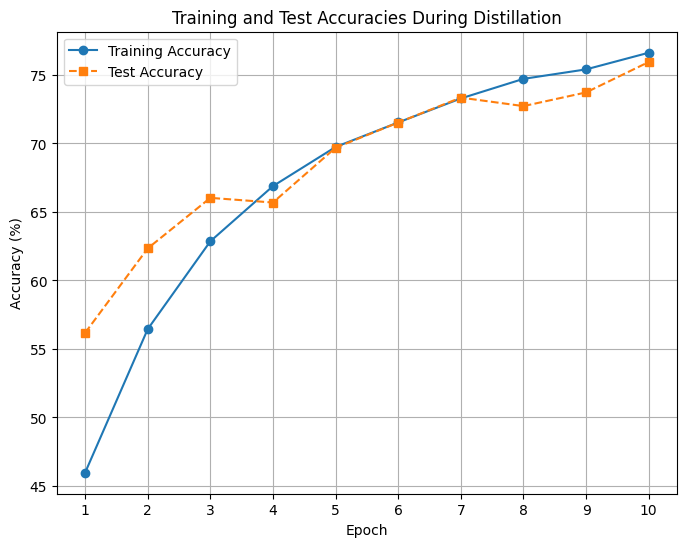

In [23]:

print("Training Student with Uniform Weighting")
distill_student(teachers, student, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=False)



In [24]:
student2 = models.resnet18(pretrained=False)
student2.fc = nn.Linear(512, 10)
student2 = student2.to(device)



Training Student with Adaptive Weighting
Accuracy: 51.32%
Epoch [1/10], Loss: 4.9600, Train Accuracy: 44.65%, Test Accuracy: 51.32%
Accuracy: 62.05%
Epoch [2/10], Loss: 3.9778, Train Accuracy: 56.32%, Test Accuracy: 62.05%
Accuracy: 64.63%
Epoch [3/10], Loss: 3.3515, Train Accuracy: 63.38%, Test Accuracy: 64.63%
Accuracy: 66.65%
Epoch [4/10], Loss: 2.9605, Train Accuracy: 67.14%, Test Accuracy: 66.65%
Accuracy: 71.18%
Epoch [5/10], Loss: 2.7191, Train Accuracy: 69.79%, Test Accuracy: 71.18%
Accuracy: 70.29%
Epoch [6/10], Loss: 2.5114, Train Accuracy: 72.15%, Test Accuracy: 70.29%
Accuracy: 73.18%
Epoch [7/10], Loss: 2.3480, Train Accuracy: 73.91%, Test Accuracy: 73.18%
Accuracy: 73.69%
Epoch [8/10], Loss: 2.2603, Train Accuracy: 74.80%, Test Accuracy: 73.69%
Accuracy: 74.19%
Epoch [9/10], Loss: 2.1105, Train Accuracy: 76.45%, Test Accuracy: 74.19%
Accuracy: 76.09%
Epoch [10/10], Loss: 1.9953, Train Accuracy: 77.52%, Test Accuracy: 76.09%


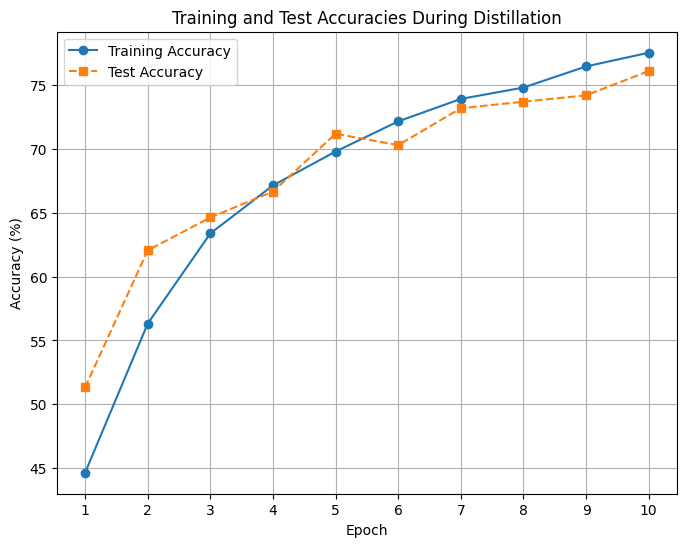

Knowledge Distillation Complete.


In [25]:
print("Training Student with Adaptive Weighting")
distill_student(teachers, student2, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True)

print("Knowledge Distillation Complete.")

Experiments

In [26]:
students=[]
student3 = models.resnet18(pretrained=False)
student3.fc = nn.Linear(512, 10)
student3 = student3.to(device)
student4 = models.resnet18(pretrained=False)
student4.fc = nn.Linear(512, 10)
student4 = student4.to(device)
student5 = models.resnet18(pretrained=False)
student5.fc = nn.Linear(512, 10)
student5 = student5.to(device)
student6 = models.resnet18(pretrained=False)
student6.fc = nn.Linear(512, 10)
student6 = student6.to(device)

for i in range(4):
  students.append(student)


Accuracy: 49.10%
Epoch [1/10], Loss: 7.1993, Train Accuracy: 44.80%, Test Accuracy: 49.10%
Accuracy: 56.83%
Epoch [2/10], Loss: 6.0371, Train Accuracy: 55.49%, Test Accuracy: 56.83%
Accuracy: 64.47%
Epoch [3/10], Loss: 5.1846, Train Accuracy: 61.99%, Test Accuracy: 64.47%
Accuracy: 67.33%
Epoch [4/10], Loss: 4.7233, Train Accuracy: 65.62%, Test Accuracy: 67.33%
Accuracy: 67.84%
Epoch [5/10], Loss: 4.3153, Train Accuracy: 69.00%, Test Accuracy: 67.84%
Accuracy: 71.79%
Epoch [6/10], Loss: 4.0139, Train Accuracy: 70.80%, Test Accuracy: 71.79%
Accuracy: 71.75%
Epoch [7/10], Loss: 3.7820, Train Accuracy: 72.82%, Test Accuracy: 71.75%
Accuracy: 72.80%
Epoch [8/10], Loss: 3.5952, Train Accuracy: 74.47%, Test Accuracy: 72.80%
Accuracy: 74.62%
Epoch [9/10], Loss: 3.4503, Train Accuracy: 75.33%, Test Accuracy: 74.62%
Accuracy: 74.39%
Epoch [10/10], Loss: 3.2922, Train Accuracy: 76.35%, Test Accuracy: 74.39%


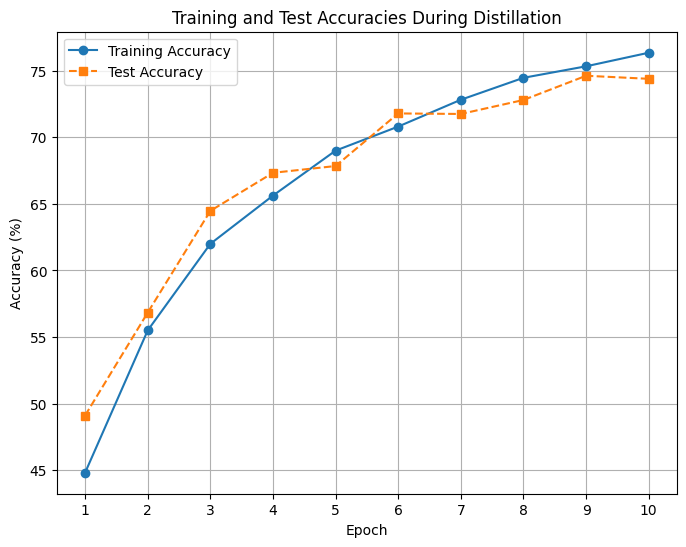

In [ ]:
distill_student(teachers, student3, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, lambda1=0.5, lambda2=0.5)



Accuracy: 42.87%
Epoch [1/10], Loss: 1.6435, Train Accuracy: 39.67%, Test Accuracy: 42.87%
Accuracy: 51.80%
Epoch [2/10], Loss: 1.5107, Train Accuracy: 47.29%, Test Accuracy: 51.80%
Accuracy: 55.34%
Epoch [3/10], Loss: 1.4269, Train Accuracy: 54.45%, Test Accuracy: 55.34%
Accuracy: 54.93%
Epoch [4/10], Loss: 1.3914, Train Accuracy: 57.69%, Test Accuracy: 54.93%
Accuracy: 61.22%
Epoch [5/10], Loss: 1.3527, Train Accuracy: 60.59%, Test Accuracy: 61.22%
Accuracy: 63.10%
Epoch [6/10], Loss: 1.3374, Train Accuracy: 62.60%, Test Accuracy: 63.10%
Accuracy: 65.84%
Epoch [7/10], Loss: 1.3299, Train Accuracy: 63.98%, Test Accuracy: 65.84%
Accuracy: 65.69%
Epoch [8/10], Loss: 1.3151, Train Accuracy: 65.25%, Test Accuracy: 65.69%
Accuracy: 64.20%
Epoch [9/10], Loss: 1.2987, Train Accuracy: 66.71%, Test Accuracy: 64.20%
Accuracy: 67.24%
Epoch [10/10], Loss: 1.2907, Train Accuracy: 67.94%, Test Accuracy: 67.24%


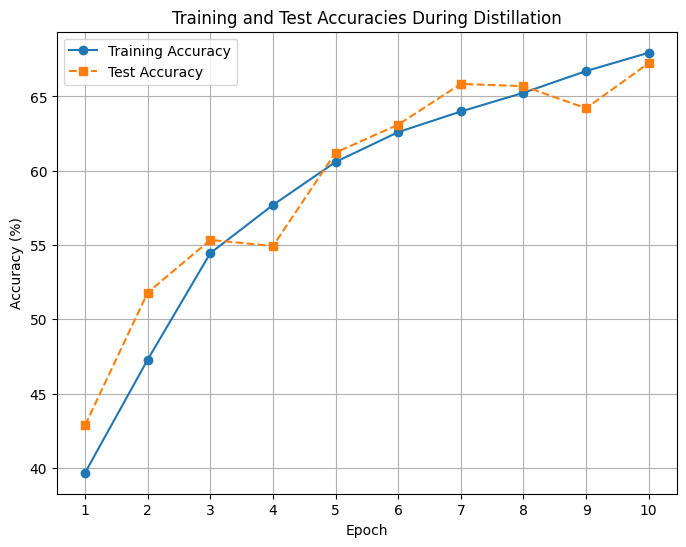

In [ ]:
distill_student(teachers, student4, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, lambda1=0.3, lambda2=0.7)


Accuracy: 51.89%
Epoch [1/10], Loss: 1.1697, Train Accuracy: 44.56%, Test Accuracy: 51.89%
Accuracy: 58.78%
Epoch [2/10], Loss: 0.9340, Train Accuracy: 55.90%, Test Accuracy: 58.78%
Accuracy: 63.48%
Epoch [3/10], Loss: 0.7930, Train Accuracy: 62.95%, Test Accuracy: 63.48%
Accuracy: 67.89%
Epoch [4/10], Loss: 0.7257, Train Accuracy: 66.51%, Test Accuracy: 67.89%
Accuracy: 67.79%
Epoch [5/10], Loss: 0.6702, Train Accuracy: 69.42%, Test Accuracy: 67.79%
Accuracy: 71.99%
Epoch [6/10], Loss: 0.6343, Train Accuracy: 71.38%, Test Accuracy: 71.99%
Accuracy: 72.39%
Epoch [7/10], Loss: 0.5997, Train Accuracy: 73.35%, Test Accuracy: 72.39%
Accuracy: 74.02%
Epoch [8/10], Loss: 0.5766, Train Accuracy: 74.50%, Test Accuracy: 74.02%
Accuracy: 74.99%
Epoch [9/10], Loss: 0.5582, Train Accuracy: 75.70%, Test Accuracy: 74.99%
Accuracy: 73.94%
Epoch [10/10], Loss: 0.5396, Train Accuracy: 76.73%, Test Accuracy: 73.94%


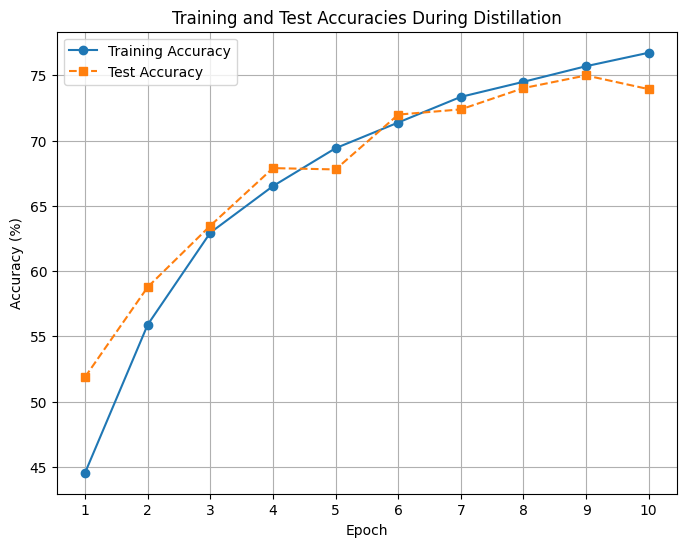

In [ ]:
distill_student(teachers, student5, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, lambda1=0.01, lambda2=0.99)


Accuracy: 51.40%
Epoch [1/10], Loss: 3.8092, Train Accuracy: 45.40%, Test Accuracy: 51.40%
Accuracy: 62.15%
Epoch [2/10], Loss: 3.0151, Train Accuracy: 57.21%, Test Accuracy: 62.15%
Accuracy: 66.13%
Epoch [3/10], Loss: 2.5165, Train Accuracy: 63.95%, Test Accuracy: 66.13%
Accuracy: 66.52%
Epoch [4/10], Loss: 2.2370, Train Accuracy: 67.72%, Test Accuracy: 66.52%
Accuracy: 70.61%
Epoch [5/10], Loss: 2.0162, Train Accuracy: 70.63%, Test Accuracy: 70.61%
Accuracy: 70.80%
Epoch [6/10], Loss: 1.8791, Train Accuracy: 72.58%, Test Accuracy: 70.80%
Accuracy: 73.49%
Epoch [7/10], Loss: 1.7712, Train Accuracy: 74.01%, Test Accuracy: 73.49%
Accuracy: 74.89%
Epoch [8/10], Loss: 1.6474, Train Accuracy: 75.75%, Test Accuracy: 74.89%
Accuracy: 74.78%
Epoch [9/10], Loss: 1.5643, Train Accuracy: 76.83%, Test Accuracy: 74.78%
Accuracy: 76.37%
Epoch [10/10], Loss: 1.5139, Train Accuracy: 77.46%, Test Accuracy: 76.37%


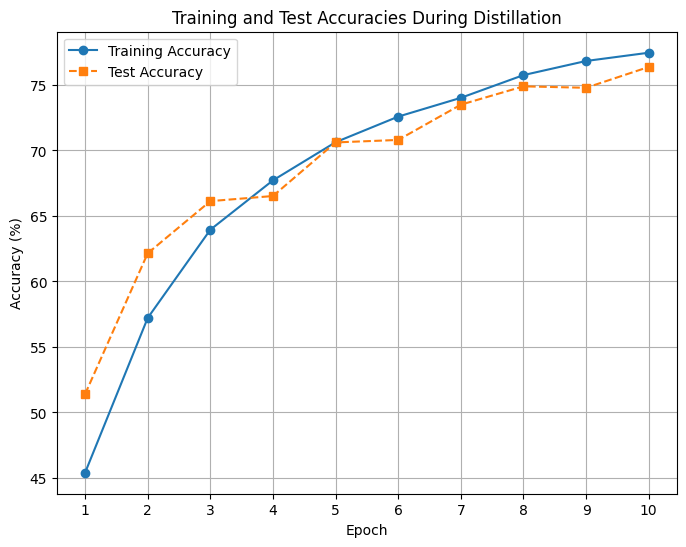

In [ ]:
distill_student(teachers, student6, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, lambda1=0.99, lambda2=0.01)


Noise

In [34]:
def distill_student_with_noise(teachers, student, valid_loader, len_batch, device='cpu', epochs=10, lr=1e-3, adaptive_weights=False, lambda1=0.7, lambda2=0.3):
    print("\nDistillation using Gaussian noise with adaptive weighting..")
    optimizer = optim.Adam(student.parameters(), lr=lr)

    accuracies_train = []  # List to store training accuracies
    accuracies_test = []   # List to store test accuracies

    for epoch in range(epochs):
        student.train()
        train_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        for _ in range(len_batch):
            # Generate Gaussian noise input
            data = torch.randn_like(next(iter(valid_loader))[0], device=device)

            # Gather teacher outputs
            teacher_outputs_list = [teacher(data).detach() for teacher in teachers]

            if adaptive_weights:
                reliabilities = [calculate_reliability(logits, lambda1, lambda2) for logits in teacher_outputs_list]
                weights = torch.tensor(reliabilities).to(device) / torch.sum(torch.tensor(reliabilities).to(device))
                combined_teacher_outputs = sum(w * logits for w, logits in zip(weights, teacher_outputs_list))
            else:
                combined_teacher_outputs = sum(teacher_outputs_list) / len(teacher_outputs_list)

            # Get student outputs
            student_outputs = student(data)

            # Compute distillation loss
            teacher_soft = nn.functional.softmax(combined_teacher_outputs / 3.0, dim=1)  # Teacher logits
            student_soft = nn.functional.log_softmax(student_outputs / 3.0, dim=1)      # Student logits
            loss = nn.KLDivLoss(reduction="batchmean")(student_soft, teacher_soft)      # KL Divergence

            # Backpropagation
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Calculate training accuracy
            _, predicted = student_outputs.max(1)
            correct_predictions += (predicted == combined_teacher_outputs.argmax(1)).sum().item()
            total_samples += data.size(0)

        # Store accuracies
        epoch_train_accuracy = 100 * correct_predictions / total_samples
        accuracies_train.append(epoch_train_accuracy)

        # Evaluate the student model on the test set
        epoch_test_accuracy = test_model(student, cifar10_test_loader)
        accuracies_test.append(epoch_test_accuracy)

        # Print epoch summary
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss / len_batch:.4f}, "
              f"Train Accuracy: {epoch_train_accuracy:.2f}%, Test Accuracy: {epoch_test_accuracy:.2f}%")

    # Plot training and test accuracies
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, epochs + 1), accuracies_train, marker='o', label='Training Accuracy')
    plt.plot(range(1, epochs + 1), accuracies_test, marker='s', label='Test Accuracy', linestyle='--')
    plt.title('Training and Test Accuracies During Gaussian Noise-Based Distillation')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.xticks(range(1, epochs + 1))
    plt.grid()
    plt.legend()
    plt.show()

In [35]:
import matplotlib.pyplot as plt


def distill_student_with_noise_and_data(
    teachers, student, valid_loader, len_batch, device='cpu', epochs=10, lr=1e-3, adaptive_weights=False, real_data_fraction=0.1, lambda1=0.7, lambda2=0.3):
    """
    Distillation using a mix of Gaussian noise and a small fraction of real data.

    Args:
        teachers: List of teacher models.
        student: Student model to train.
        valid_loader: Validation DataLoader (used to sample real data).
        len_batch: Number of batches per epoch.
        device: Device to run the training on.
        epochs: Number of epochs for training.
        lr: Learning rate for optimizer.
        adaptive_weights: Whether to use adaptive weighting for teacher outputs.
        real_data_fraction: Fraction of real data in each batch.
    """
    print("\nDistillation using a mix of Gaussian noise and real data..")
    optimizer = optim.Adam(student.parameters(), lr=lr)
    T = 3.0  # Temperature for distillation

    accuracies_train = []  # Store training accuracies
    accuracies_test = []   # Store test accuracies

    for epoch in range(epochs):
        student.train()
        train_loss = 0.0
        correct_predictions = 0
        total_samples = 0

        valid_iter = iter(valid_loader)  # Iterator for real data

        for _ in range(len_batch):
            # Create a batch of inputs with real data and Gaussian noise
            try:
                real_data_batch, _ = next(valid_iter)  # Get real data
            except StopIteration:  # Restart the iterator if exhausted
                valid_iter = iter(valid_loader)
                real_data_batch, _ = next(valid_iter)

            real_data_batch = real_data_batch.to(device)
            batch_size = real_data_batch.size(0)
            num_real_samples = int(real_data_fraction * batch_size)
            num_noise_samples = batch_size - num_real_samples

            # Take a subset of real data
            real_data = real_data_batch[:num_real_samples]
            # Generate Gaussian noise for the rest
            noise_data = torch.randn((num_noise_samples,) + real_data_batch.shape[1:], device=device)

            # Combine real data and Gaussian noise
            data = torch.cat([real_data, noise_data], dim=0)

            # Gather teacher outputs
            teacher_outputs_list = [teacher(data).detach() for teacher in teachers]

            if adaptive_weights:
                reliabilities = [calculate_reliability(logits, lambda1, lambda2) for logits in teacher_outputs_list]
                weights = torch.tensor(reliabilities).to(device) / torch.sum(torch.tensor(reliabilities).to(device))
                combined_teacher_outputs = sum(w * logits for w, logits in zip(weights, teacher_outputs_list))
            else:
                combined_teacher_outputs = sum(teacher_outputs_list) / len(teacher_outputs_list)

            # Student predictions
            student_outputs = student(data)

            # Compute distillation loss
            teacher_soft = nn.functional.softmax(combined_teacher_outputs / T, dim=1)
            student_soft = nn.functional.log_softmax(student_outputs / T, dim=1)
            loss = nn.functional.kl_div(student_soft, teacher_soft, reduction="batchmean") * (T ** 2)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

            # Calculate training accuracy
            _, predicted = student_outputs.max(1)
            correct_predictions += (predicted == combined_teacher_outputs.argmax(1)).sum().item()
            total_samples += data.size(0)

        # Calculate and store accuracies
        epoch_train_accuracy = 100 * correct_predictions / total_samples
        accuracies_train.append(epoch_train_accuracy)

        # Evaluate the student model on the test set
        epoch_test_accuracy = test_model(student, cifar10_test_loader)
        accuracies_test.append(epoch_test_accuracy)

        print(f"Epoch [{epoch+1}/{epochs}], Loss: {train_loss / len_batch:.4f}, "
              f"Train Accuracy: {epoch_train_accuracy:.2f}%, Test Accuracy: {epoch_test_accuracy:.2f}%")

    # Plot training and test accuracies
    plt.figure(figsize=(8, 6))
    plt.plot(range(1, epochs + 1), accuracies_train, marker='o', label='Training Accuracy')
    plt.plot(range(1, epochs + 1), accuracies_test, marker='s', label='Test Accuracy', linestyle='--')
    plt.title('Training and Test Accuracies During Distillation with Noise and Real Data')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy (%)')
    plt.xticks(range(1, epochs + 1))
    plt.grid()
    plt.legend()
    plt.show()


In [36]:
student = models.resnet18(pretrained=False)
student.fc = nn.Linear(512, 10)
student = student.to(device)
student2 = models.resnet18(pretrained=False)
student2.fc = nn.Linear(512, 10)
student2 = student2.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)


In [ ]:
for teacher in teachers:
  teacher.eval()


Distillation using Gaussian noise with adaptive weighting..
Accuracy: 10.00%
Epoch [1/10], Loss: 0.0069, Train Accuracy: 71.81%, Test Accuracy: 10.00%
Accuracy: 10.35%
Epoch [2/10], Loss: 0.0043, Train Accuracy: 77.14%, Test Accuracy: 10.35%
Accuracy: 10.06%
Epoch [3/10], Loss: 0.0040, Train Accuracy: 77.31%, Test Accuracy: 10.06%
Accuracy: 13.14%
Epoch [4/10], Loss: 0.0039, Train Accuracy: 76.92%, Test Accuracy: 13.14%
Accuracy: 13.01%
Epoch [5/10], Loss: 0.0038, Train Accuracy: 77.43%, Test Accuracy: 13.01%
Accuracy: 12.23%
Epoch [6/10], Loss: 0.0038, Train Accuracy: 77.21%, Test Accuracy: 12.23%
Accuracy: 13.32%
Epoch [7/10], Loss: 0.0037, Train Accuracy: 77.58%, Test Accuracy: 13.32%
Accuracy: 12.14%
Epoch [8/10], Loss: 0.0036, Train Accuracy: 77.59%, Test Accuracy: 12.14%
Accuracy: 13.57%
Epoch [9/10], Loss: 0.0036, Train Accuracy: 77.17%, Test Accuracy: 13.57%
Accuracy: 13.26%
Epoch [10/10], Loss: 0.0035, Train Accuracy: 77.37%, Test Accuracy: 13.26%


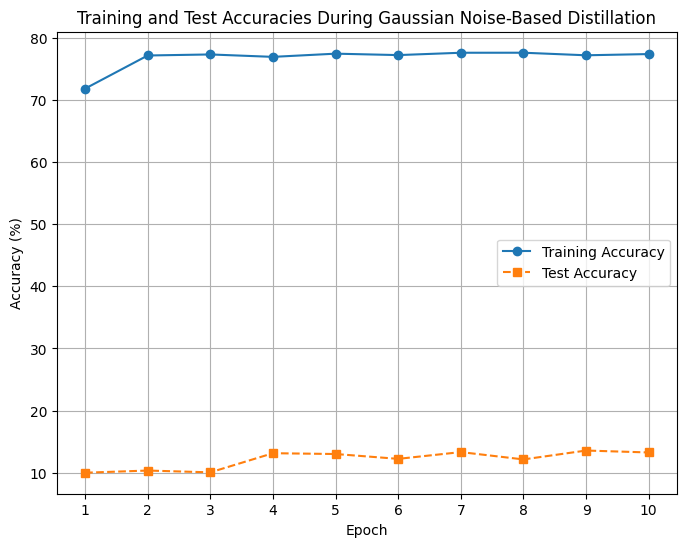


Distillation using a mix of Gaussian noise and real data..
Accuracy: 30.48%
Epoch [1/10], Loss: 0.1696, Train Accuracy: 70.43%, Test Accuracy: 30.48%
Accuracy: 34.76%
Epoch [2/10], Loss: 0.1388, Train Accuracy: 72.87%, Test Accuracy: 34.76%
Accuracy: 35.77%
Epoch [3/10], Loss: 0.1267, Train Accuracy: 73.54%, Test Accuracy: 35.77%
Accuracy: 37.13%
Epoch [4/10], Loss: 0.1213, Train Accuracy: 73.40%, Test Accuracy: 37.13%
Accuracy: 40.84%
Epoch [5/10], Loss: 0.1168, Train Accuracy: 73.77%, Test Accuracy: 40.84%
Accuracy: 42.70%
Epoch [6/10], Loss: 0.1123, Train Accuracy: 73.77%, Test Accuracy: 42.70%
Accuracy: 45.98%
Epoch [7/10], Loss: 0.1085, Train Accuracy: 74.29%, Test Accuracy: 45.98%
Accuracy: 46.22%
Epoch [8/10], Loss: 0.1055, Train Accuracy: 74.65%, Test Accuracy: 46.22%
Accuracy: 51.97%
Epoch [9/10], Loss: 0.1013, Train Accuracy: 74.60%, Test Accuracy: 51.97%
Accuracy: 47.76%
Epoch [10/10], Loss: 0.0985, Train Accuracy: 74.98%, Test Accuracy: 47.76%


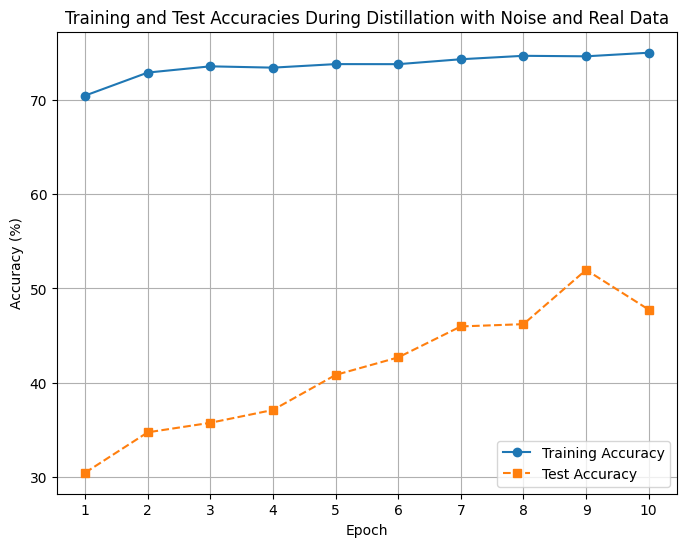

In [ ]:
# Dataloaders
cifar10_train_loader = DataLoader(cifar10_train, batch_size=256, shuffle=True)
cifar10_test_loader = DataLoader(cifar10_test, batch_size=256, shuffle=False)
distill_student_with_noise(teachers, student, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=False,  len_batch=195)
distill_student_with_noise_and_data(teachers, student2, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=False, real_data_fraction=0.1, len_batch=195)


Distillation using Gaussian noise with adaptive weighting..
Accuracy: 10.00%
Epoch [1/10], Loss: 0.0093, Train Accuracy: 79.62%, Test Accuracy: 10.00%
Accuracy: 11.17%
Epoch [2/10], Loss: 0.0061, Train Accuracy: 83.01%, Test Accuracy: 11.17%
Accuracy: 12.37%
Epoch [3/10], Loss: 0.0059, Train Accuracy: 83.00%, Test Accuracy: 12.37%
Accuracy: 13.79%
Epoch [4/10], Loss: 0.0057, Train Accuracy: 82.79%, Test Accuracy: 13.79%
Accuracy: 14.55%
Epoch [5/10], Loss: 0.0056, Train Accuracy: 83.48%, Test Accuracy: 14.55%
Accuracy: 14.69%
Epoch [6/10], Loss: 0.0054, Train Accuracy: 83.11%, Test Accuracy: 14.69%
Accuracy: 14.99%
Epoch [7/10], Loss: 0.0054, Train Accuracy: 83.47%, Test Accuracy: 14.99%
Accuracy: 14.58%
Epoch [8/10], Loss: 0.0053, Train Accuracy: 83.19%, Test Accuracy: 14.58%
Accuracy: 14.38%
Epoch [9/10], Loss: 0.0052, Train Accuracy: 83.05%, Test Accuracy: 14.38%
Accuracy: 14.95%
Epoch [10/10], Loss: 0.0051, Train Accuracy: 83.42%, Test Accuracy: 14.95%


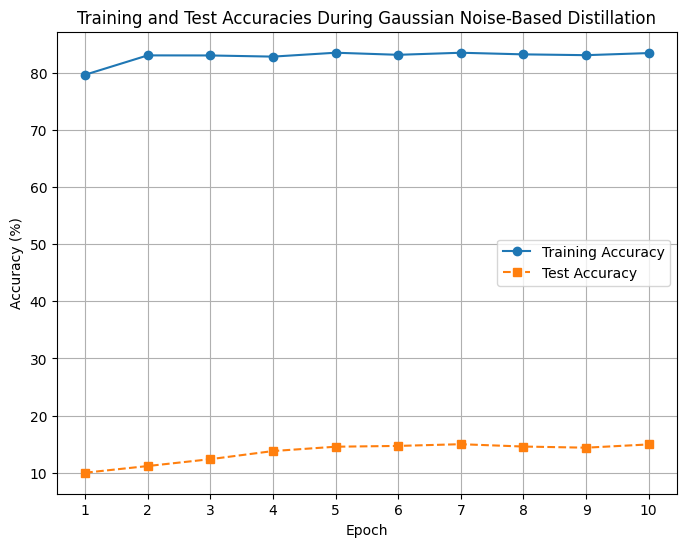


Distillation using a mix of Gaussian noise and real data..
Accuracy: 31.45%
Epoch [1/10], Loss: 0.2130, Train Accuracy: 72.92%, Test Accuracy: 31.45%
Accuracy: 32.75%
Epoch [2/10], Loss: 0.1713, Train Accuracy: 75.27%, Test Accuracy: 32.75%
Accuracy: 41.00%
Epoch [3/10], Loss: 0.1593, Train Accuracy: 75.50%, Test Accuracy: 41.00%
Accuracy: 37.13%
Epoch [4/10], Loss: 0.1503, Train Accuracy: 75.84%, Test Accuracy: 37.13%
Accuracy: 42.53%
Epoch [5/10], Loss: 0.1475, Train Accuracy: 76.28%, Test Accuracy: 42.53%
Accuracy: 44.95%
Epoch [6/10], Loss: 0.1404, Train Accuracy: 76.14%, Test Accuracy: 44.95%
Accuracy: 43.01%
Epoch [7/10], Loss: 0.1364, Train Accuracy: 76.67%, Test Accuracy: 43.01%
Accuracy: 48.31%
Epoch [8/10], Loss: 0.1335, Train Accuracy: 76.77%, Test Accuracy: 48.31%
Accuracy: 44.99%
Epoch [9/10], Loss: 0.1288, Train Accuracy: 77.22%, Test Accuracy: 44.99%
Accuracy: 46.99%
Epoch [10/10], Loss: 0.1269, Train Accuracy: 77.23%, Test Accuracy: 46.99%


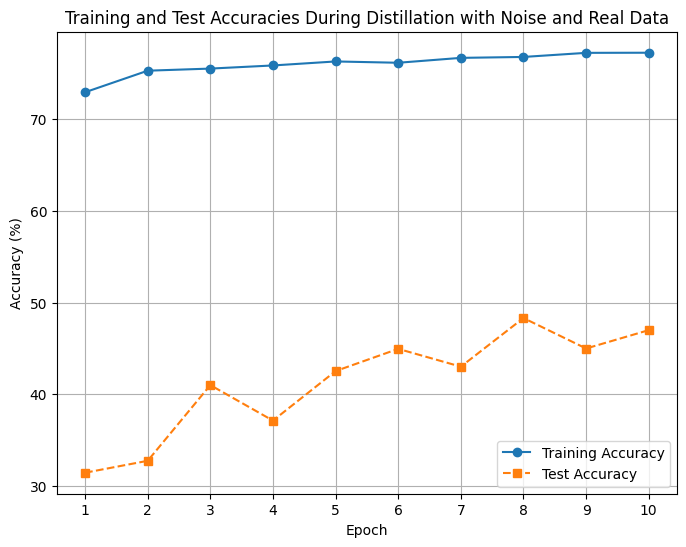

In [37]:
cifar10_train_loader = DataLoader(cifar10_train, batch_size=256, shuffle=True)
cifar10_test_loader = DataLoader(cifar10_test, batch_size=256, shuffle=False)
distill_student_with_noise(teachers, student, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True,  len_batch=195)
distill_student_with_noise_and_data(teachers, student2, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, real_data_fraction=0.1, len_batch=195)

In [ ]:
student3 = models.resnet18(pretrained=False)
student3.fc = nn.Linear(512, 10)
student3 = student3.to(device)
student4 = models.resnet18(pretrained=False)
student4.fc = nn.Linear(512, 10)
student4 = student4.to(device)
student5 = models.resnet18(pretrained=False)
student5.fc = nn.Linear(512, 10)
student5 = student5.to(device)
student6 = models.resnet18(pretrained=False)
student6.fc = nn.Linear(512, 10)
student6 = student6.to(device)
student7 = models.resnet18(pretrained=False)
student7.fc = nn.Linear(512, 10)
student7 = student7.to(device)
student8 = models.resnet18(pretrained=False)
student8.fc = nn.Linear(512, 10)
student8 = student8.to(device)
student9 = models.resnet18(pretrained=False)
student9.fc = nn.Linear(512, 10)
student9 = student9.to(device)
student10 = models.resnet18(pretrained=False)
student10.fc = nn.Linear(512, 10)
student10 = student10.to(device)

/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.10/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=None`.
  warnings.warn(msg)



Distillation using Gaussian noise with adaptive weighting..
Accuracy: 10.00%
Epoch [1/10], Loss: 0.0083, Train Accuracy: 89.35%, Test Accuracy: 10.00%
Accuracy: 10.01%
Epoch [2/10], Loss: 0.0058, Train Accuracy: 91.42%, Test Accuracy: 10.01%
Accuracy: 10.45%
Epoch [3/10], Loss: 0.0055, Train Accuracy: 91.41%, Test Accuracy: 10.45%
Accuracy: 13.59%
Epoch [4/10], Loss: 0.0053, Train Accuracy: 91.29%, Test Accuracy: 13.59%
Accuracy: 13.17%
Epoch [5/10], Loss: 0.0052, Train Accuracy: 91.35%, Test Accuracy: 13.17%
Accuracy: 15.27%
Epoch [6/10], Loss: 0.0051, Train Accuracy: 91.48%, Test Accuracy: 15.27%
Accuracy: 12.59%
Epoch [7/10], Loss: 0.0050, Train Accuracy: 91.30%, Test Accuracy: 12.59%
Accuracy: 15.00%
Epoch [8/10], Loss: 0.0050, Train Accuracy: 91.47%, Test Accuracy: 15.00%
Accuracy: 12.00%
Epoch [9/10], Loss: 0.0048, Train Accuracy: 91.10%, Test Accuracy: 12.00%
Accuracy: 15.31%
Epoch [10/10], Loss: 0.0048, Train Accuracy: 91.33%, Test Accuracy: 15.31%


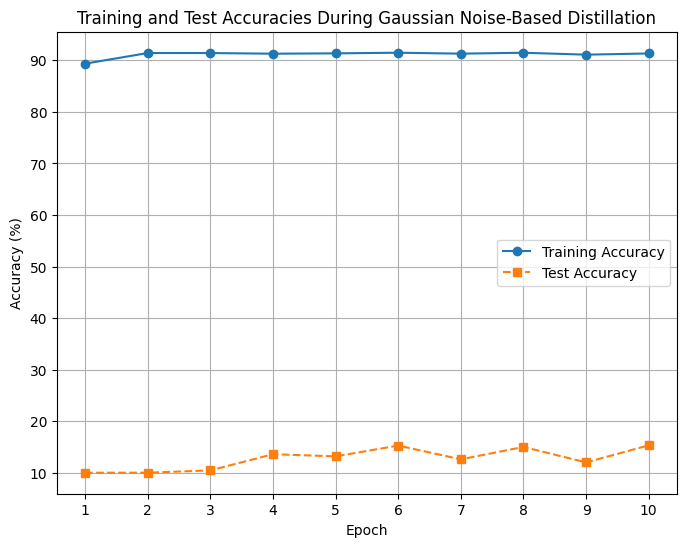


Distillation using a mix of Gaussian noise and real data..
Accuracy: 30.42%
Epoch [1/10], Loss: 0.1977, Train Accuracy: 82.33%, Test Accuracy: 30.42%
Accuracy: 37.36%
Epoch [2/10], Loss: 0.1582, Train Accuracy: 84.17%, Test Accuracy: 37.36%
Accuracy: 37.94%
Epoch [3/10], Loss: 0.1500, Train Accuracy: 84.62%, Test Accuracy: 37.94%
Accuracy: 42.35%
Epoch [4/10], Loss: 0.1427, Train Accuracy: 84.58%, Test Accuracy: 42.35%
Accuracy: 43.58%
Epoch [5/10], Loss: 0.1350, Train Accuracy: 85.07%, Test Accuracy: 43.58%
Accuracy: 42.32%
Epoch [6/10], Loss: 0.1300, Train Accuracy: 85.32%, Test Accuracy: 42.32%
Accuracy: 46.51%
Epoch [7/10], Loss: 0.1274, Train Accuracy: 85.62%, Test Accuracy: 46.51%
Accuracy: 48.11%
Epoch [8/10], Loss: 0.1240, Train Accuracy: 85.38%, Test Accuracy: 48.11%
Accuracy: 47.88%
Epoch [9/10], Loss: 0.1198, Train Accuracy: 85.94%, Test Accuracy: 47.88%
Accuracy: 50.73%
Epoch [10/10], Loss: 0.1149, Train Accuracy: 86.08%, Test Accuracy: 50.73%


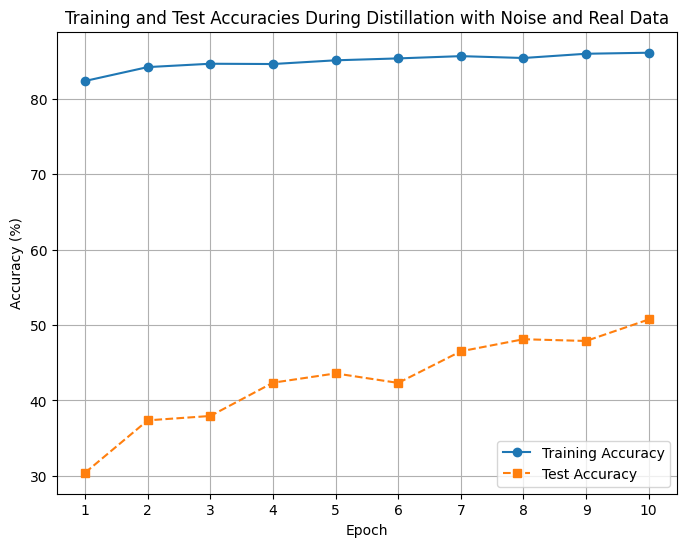

In [ ]:
distill_student_with_noise(teachers, student3, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, len_batch=195, lambda1=0.5, lambda2=0.5)
distill_student_with_noise_and_data(teachers, student4, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, len_batch=195, lambda1=0.5, lambda2=0.5)



Distillation using Gaussian noise with adaptive weighting..
Accuracy: 10.00%
Epoch [1/10], Loss: 0.0086, Train Accuracy: 89.49%, Test Accuracy: 10.00%
Accuracy: 10.00%
Epoch [2/10], Loss: 0.0058, Train Accuracy: 91.50%, Test Accuracy: 10.00%
Accuracy: 10.04%
Epoch [3/10], Loss: 0.0056, Train Accuracy: 91.39%, Test Accuracy: 10.04%
Accuracy: 10.31%
Epoch [4/10], Loss: 0.0054, Train Accuracy: 91.33%, Test Accuracy: 10.31%
Accuracy: 12.02%
Epoch [5/10], Loss: 0.0053, Train Accuracy: 91.59%, Test Accuracy: 12.02%
Accuracy: 12.10%
Epoch [6/10], Loss: 0.0053, Train Accuracy: 91.52%, Test Accuracy: 12.10%
Accuracy: 13.10%
Epoch [7/10], Loss: 0.0051, Train Accuracy: 91.53%, Test Accuracy: 13.10%
Accuracy: 13.61%
Epoch [8/10], Loss: 0.0051, Train Accuracy: 91.46%, Test Accuracy: 13.61%
Accuracy: 13.27%
Epoch [9/10], Loss: 0.0050, Train Accuracy: 91.38%, Test Accuracy: 13.27%
Accuracy: 14.02%
Epoch [10/10], Loss: 0.0049, Train Accuracy: 91.45%, Test Accuracy: 14.02%


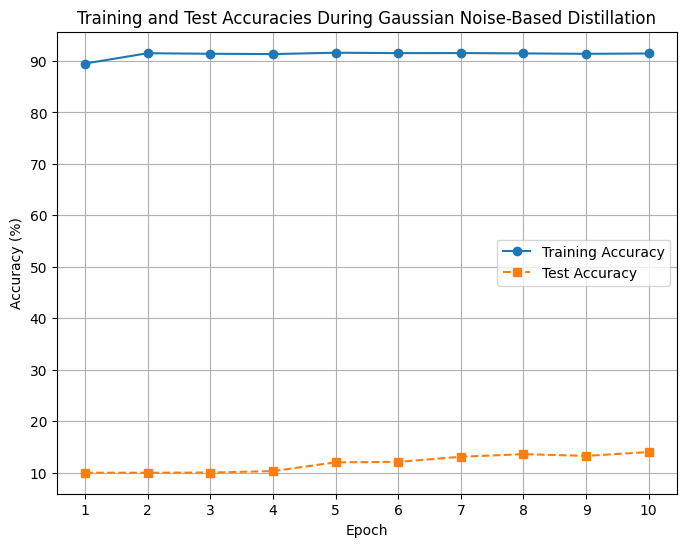


Distillation using a mix of Gaussian noise and real data..
Accuracy: 34.15%
Epoch [1/10], Loss: 0.2026, Train Accuracy: 82.76%, Test Accuracy: 34.15%
Accuracy: 38.58%
Epoch [2/10], Loss: 0.1624, Train Accuracy: 84.31%, Test Accuracy: 38.58%
Accuracy: 36.93%
Epoch [3/10], Loss: 0.1554, Train Accuracy: 84.47%, Test Accuracy: 36.93%
Accuracy: 37.91%
Epoch [4/10], Loss: 0.1431, Train Accuracy: 85.17%, Test Accuracy: 37.91%
Accuracy: 39.49%
Epoch [5/10], Loss: 0.1408, Train Accuracy: 85.27%, Test Accuracy: 39.49%
Accuracy: 43.05%
Epoch [6/10], Loss: 0.1330, Train Accuracy: 85.38%, Test Accuracy: 43.05%
Accuracy: 48.79%
Epoch [7/10], Loss: 0.1277, Train Accuracy: 85.39%, Test Accuracy: 48.79%
Accuracy: 47.21%
Epoch [8/10], Loss: 0.1240, Train Accuracy: 85.75%, Test Accuracy: 47.21%
Accuracy: 51.35%
Epoch [9/10], Loss: 0.1196, Train Accuracy: 86.25%, Test Accuracy: 51.35%
Accuracy: 51.35%
Epoch [10/10], Loss: 0.1161, Train Accuracy: 86.16%, Test Accuracy: 51.35%


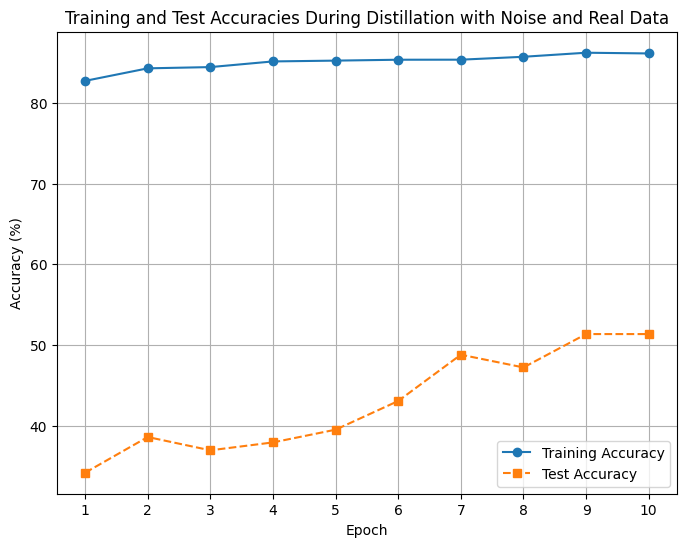

In [ ]:
distill_student_with_noise(teachers, student5, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, len_batch=195, lambda1=0.3, lambda2=0.7)
distill_student_with_noise_and_data(teachers, student6, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, len_batch=195, lambda1=0.3, lambda2=0.7)



Distillation using Gaussian noise with adaptive weighting..
Accuracy: 10.00%
Epoch [1/10], Loss: 0.0108, Train Accuracy: 78.09%, Test Accuracy: 10.00%
Accuracy: 10.00%
Epoch [2/10], Loss: 0.0068, Train Accuracy: 83.21%, Test Accuracy: 10.00%
Accuracy: 10.00%
Epoch [3/10], Loss: 0.0063, Train Accuracy: 84.09%, Test Accuracy: 10.00%
Accuracy: 10.70%
Epoch [4/10], Loss: 0.0061, Train Accuracy: 83.53%, Test Accuracy: 10.70%
Accuracy: 13.31%
Epoch [5/10], Loss: 0.0061, Train Accuracy: 83.10%, Test Accuracy: 13.31%
Accuracy: 12.27%
Epoch [6/10], Loss: 0.0059, Train Accuracy: 83.18%, Test Accuracy: 12.27%
Accuracy: 12.59%
Epoch [7/10], Loss: 0.0058, Train Accuracy: 83.02%, Test Accuracy: 12.59%
Accuracy: 13.76%
Epoch [8/10], Loss: 0.0056, Train Accuracy: 83.69%, Test Accuracy: 13.76%
Accuracy: 14.20%
Epoch [9/10], Loss: 0.0056, Train Accuracy: 83.28%, Test Accuracy: 14.20%
Accuracy: 14.67%
Epoch [10/10], Loss: 0.0056, Train Accuracy: 83.49%, Test Accuracy: 14.67%


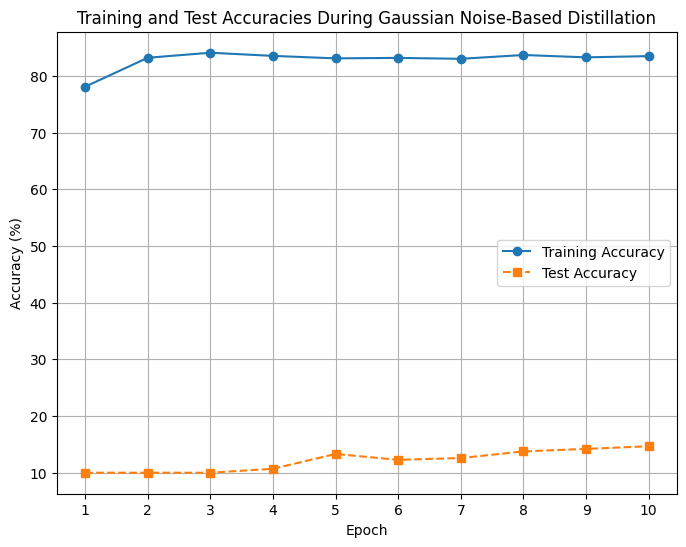


Distillation using a mix of Gaussian noise and real data..
Accuracy: 22.65%
Epoch [1/10], Loss: 0.2249, Train Accuracy: 71.43%, Test Accuracy: 22.65%
Accuracy: 21.87%
Epoch [2/10], Loss: 0.1877, Train Accuracy: 74.31%, Test Accuracy: 21.87%
Accuracy: 27.29%
Epoch [3/10], Loss: 0.1806, Train Accuracy: 74.01%, Test Accuracy: 27.29%
Accuracy: 29.40%
Epoch [4/10], Loss: 0.1721, Train Accuracy: 74.28%, Test Accuracy: 29.40%
Accuracy: 29.83%
Epoch [5/10], Loss: 0.1718, Train Accuracy: 75.38%, Test Accuracy: 29.83%
Accuracy: 26.66%
Epoch [6/10], Loss: 0.1649, Train Accuracy: 74.86%, Test Accuracy: 26.66%
Accuracy: 32.30%
Epoch [7/10], Loss: 0.1628, Train Accuracy: 74.58%, Test Accuracy: 32.30%
Accuracy: 30.28%
Epoch [8/10], Loss: 0.1602, Train Accuracy: 75.09%, Test Accuracy: 30.28%
Accuracy: 32.96%
Epoch [9/10], Loss: 0.1593, Train Accuracy: 74.45%, Test Accuracy: 32.96%
Accuracy: 27.89%
Epoch [10/10], Loss: 0.1488, Train Accuracy: 75.95%, Test Accuracy: 27.89%


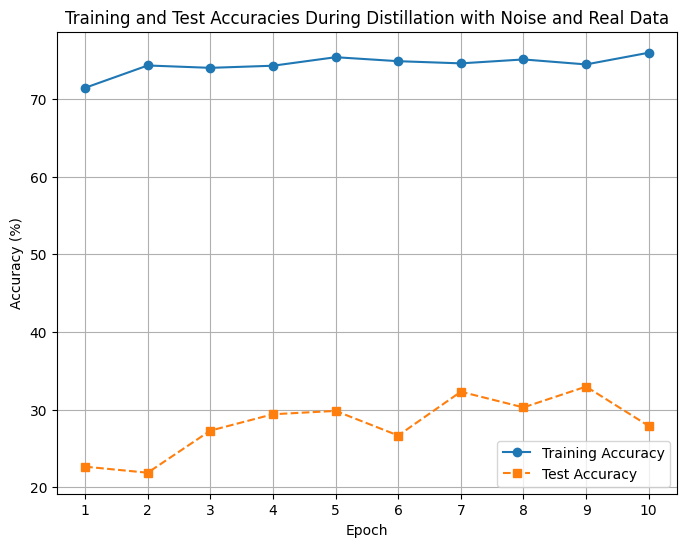

In [ ]:
distill_student_with_noise(teachers, student7, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, len_batch=195, lambda1=0.01, lambda2=0.99)
distill_student_with_noise_and_data(teachers, student8, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, len_batch=195, lambda1=0.01, lambda2=0.99)



Distillation using Gaussian noise with adaptive weighting..
Accuracy: 10.23%
Epoch [1/10], Loss: 0.0106, Train Accuracy: 76.43%, Test Accuracy: 10.23%
Accuracy: 10.00%
Epoch [2/10], Loss: 0.0070, Train Accuracy: 82.20%, Test Accuracy: 10.00%
Accuracy: 11.83%
Epoch [3/10], Loss: 0.0066, Train Accuracy: 82.55%, Test Accuracy: 11.83%
Accuracy: 10.67%
Epoch [4/10], Loss: 0.0062, Train Accuracy: 82.15%, Test Accuracy: 10.67%
Accuracy: 11.25%
Epoch [5/10], Loss: 0.0061, Train Accuracy: 83.54%, Test Accuracy: 11.25%
Accuracy: 13.48%
Epoch [6/10], Loss: 0.0060, Train Accuracy: 82.64%, Test Accuracy: 13.48%
Accuracy: 12.96%
Epoch [7/10], Loss: 0.0059, Train Accuracy: 82.56%, Test Accuracy: 12.96%
Accuracy: 13.51%
Epoch [8/10], Loss: 0.0058, Train Accuracy: 84.05%, Test Accuracy: 13.51%
Accuracy: 12.29%
Epoch [9/10], Loss: 0.0059, Train Accuracy: 83.15%, Test Accuracy: 12.29%
Accuracy: 13.73%
Epoch [10/10], Loss: 0.0057, Train Accuracy: 82.22%, Test Accuracy: 13.73%


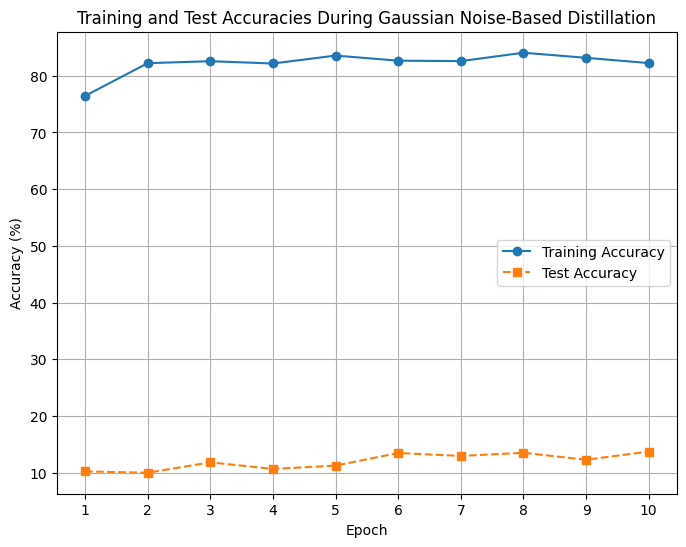


Distillation using a mix of Gaussian noise and real data..
Accuracy: 24.19%
Epoch [1/10], Loss: 0.2615, Train Accuracy: 71.99%, Test Accuracy: 24.19%
Accuracy: 27.04%
Epoch [2/10], Loss: 0.2065, Train Accuracy: 74.21%, Test Accuracy: 27.04%
Accuracy: 25.46%
Epoch [3/10], Loss: 0.1935, Train Accuracy: 74.53%, Test Accuracy: 25.46%
Accuracy: 26.77%
Epoch [4/10], Loss: 0.1895, Train Accuracy: 75.20%, Test Accuracy: 26.77%
Accuracy: 30.27%
Epoch [5/10], Loss: 0.1805, Train Accuracy: 74.53%, Test Accuracy: 30.27%
Accuracy: 32.64%
Epoch [6/10], Loss: 0.1812, Train Accuracy: 74.23%, Test Accuracy: 32.64%
Accuracy: 30.23%
Epoch [7/10], Loss: 0.1723, Train Accuracy: 74.66%, Test Accuracy: 30.23%
Accuracy: 32.35%
Epoch [8/10], Loss: 0.1744, Train Accuracy: 74.63%, Test Accuracy: 32.35%
Accuracy: 33.34%
Epoch [9/10], Loss: 0.1716, Train Accuracy: 75.59%, Test Accuracy: 33.34%
Accuracy: 34.42%
Epoch [10/10], Loss: 0.1711, Train Accuracy: 75.42%, Test Accuracy: 34.42%


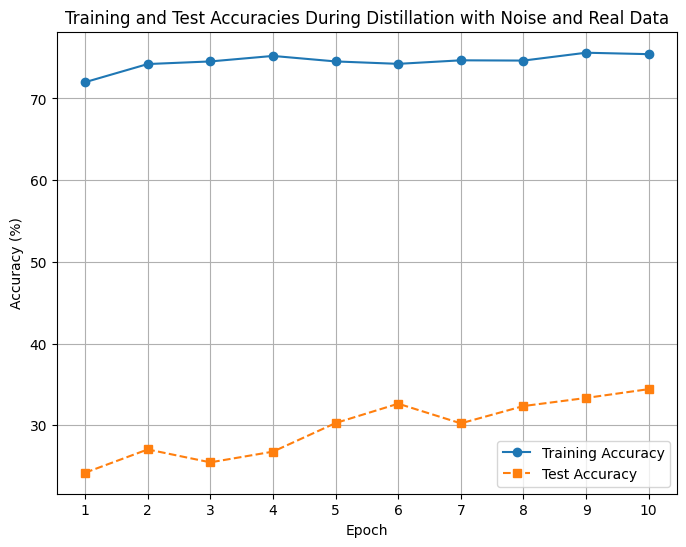

In [ ]:
distill_student_with_noise(teachers, student9, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, len_batch=195, lambda1=0.99, lambda2=0.01)
distill_student_with_noise_and_data(teachers, student10, cifar10_train_loader, device=device, epochs=10, lr=1e-3, adaptive_weights=True, len_batch=195, lambda1=0.99, lambda2=0.01)
